# Semana 5 · Transformación de variables (Python)

**Práctica obligatoria · 2 pomodoros (40 minutos)**

En este notebook vamos a continuar con el proceso de limpieza y preparación de datos. En este caso, trataremos específicamente la transformación de datos. Es decir, modificar los datos de acuerdo a ciertas reglas para mejorar aun más el dataset y tenerlo listo para la fase de procesamiento.

> Realizá esta versión o la versión en R. No es necesario completar ambas.


## Resultados esperados

Al finalizar deberías poder:

- diferenciar limpieza y transformación de datos;
- discretizar y codificar variables con criterios adecuados;
- normalizar o estandarizar variables numéricas;
- crear variables derivadas y temporales;
- conservar intactos los datos originales;
- comparar resultados y completar una bitácora de transformaciones.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

pd.set_option("display.max_columns", None)

: 

# Práctica resuelta

## Dataset

Trabajaremos con el dataset 'Diamonds'. Este dataset contiene los precios y otros atributos de casi 54.000 diamantes.

Aquí se describen en detalle las variables del dataset:

| Variable      | Descripción|
| :------------ | :-|
| `carat`    | Peso del diamante (quilates)|
| `cut`      | Calidad del corte del diamante|
| `color`        | Color del diamante, desde J (peor) hasta D (mejor)|
| `clarity`         | Una medida de cuáns limpio está el diamante (I1 (peor), SI2, SI1, * VS2, VS1, VVS2, VVS1, IF (mejor))|
| `depth`      | porcentaje de profundidad total. Medida como `z / mean(x, y) = 2 * z / (x + y)`|
| `table`        | Ancho de la parte superior del diamante en relación con el punto más ancho|
| `price` | Precio en dólares ($)|
| `x`         | largo (mm).|
| `y`       | ancho (mm)|
| `z`       | profundidad (mm)|


Fuente dataset: `https://www.kaggle.com/datasets/shivam2503/diamonds`

In [2]:
df_diamonds = sns.load_dataset('diamonds')

## Diagnóstico inicial

Ahora hacemos una breve observación del dataset. Veamos las primeras 5 filas del dataset

In [3]:
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Revisemos cuántas variables posee y registros posee

In [4]:
# Tamaño del dataset (cant_filas, cant_columnas)
df_diamonds.shape

(53940, 10)

In [5]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


Se observa que posee 53940 registros (diamantes), 10 variables de los cuales:
* 3 variables cualitativas (pueden ser tratados como ordinales)
* 7 variables cuantitativas continuas.

Ahora observemos un resumen estadístico de todas las variables cuantitativas

In [6]:
df_diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
display(df_diamonds['cut'].value_counts())
display(df_diamonds['color'].value_counts())
display(df_diamonds['clarity'].value_counts())

,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


,count
color,
G,11292
E,9797
F,9542
H,8304
D,6775
I,5422
J,2808


,count
clarity,
SI1,13065
VS2,12258
SI2,9194
VS1,8171
VVS2,5066
VVS1,3655
IF,1790
I1,741


Aquí podemos hacer algunas aclaraciones importantes:

* La variable `price` está fuertemente sesgada a la derecha: su media (3932,80) es bastante mayor que su mediana (2401), y el máximo (18823) está muy por encima del tercer cuartil (5324,25). Es decir, la mayoría de los diamantes son relativamente económicos y unos pocos, muy caros, estiran la distribución hacia arriba. Algo similar, aunque más leve, ocurre con `carat` (media 0,80 vs. mediana 0,70).
* Las variables `x`, `y` y `z` (dimensiones físicas del diamante en milímetros) tienen un valor mínimo de 0, algo que no tiene sentido físico. Esto deberá ser considerado en un trabajo de limpieza de datos.
* `y` y `z` muestran máximos muy alejados del resto de la distribución (58,90 y 31,80 respectivamente, frente a percentiles 75 de apenas 6,54 y 4,04).
* `depth` y `table` tienen una dispersión mucho más acotada en relación a su media (desvíos estándar de solo 1,43 y 2,23 sobre medias de 61,75 y 57,46). Tiene sentido: son proporciones relacionadas con el tallado del diamante, limitadas por estándares de corte, a diferencia de variables como `price` o `carat` que no tienen ese techo natural.
* En cuanto a las variables cualitativas: `cut` está bastante desbalanceada, con `Ideal` como categoría ampliamente mayoritaria (21.551 registros) frente a `Fair` (1.610), la menos frecuente. `clarity` muestra un patrón parecido: `SI1` y `VS2` concentran buena parte de los registros, mientras que `I1` (la peor claridad posible) es la categoría con menos casos. `color` es la más equilibrada de las tres, aunque igual predomina el color `G` por sobre el resto.
* Este desbalance en las categóricas conviene tenerlo presente más adelante, cuando trabajemos con `cut` y `color` en la sección de numerización: una categoría muy poco representada puede quedar subrepresentada en un análisis o modelo posterior.

## Limpieza de datos

Ahora hagamos un análisis rápido sobre la calidad del dataset.

Primero hagamos una copia del dataset original y luego revisemos la existencia de valores duplicados.

In [8]:
df_diamonds_orig = df_diamonds.copy()

In [9]:
df_diamonds.duplicated().sum()

np.int64(146)

Existen 146 filas duplicadas. Un paso importante es analizar si estas filas corresponden a diamantes distintos o son registros duplicados de los mismos. Para este caso, supondremos que el segundo caso es el que se nos presenta, por lo que eliminaremos estas filas. Cabe considerar que esta eliminación borra el 0,27% del total del dataset y su modificación es insignificante.

In [10]:
# Borro las filas duplicadas
df_diamonds.drop_duplicates(inplace=True)

# Verifico que las filas duplicadas se hayan borrado
df_diamonds.duplicated().sum()

np.int64(0)

Ahora continuamos con el tratamiento de valores nulos. Sin embargo, este dataset no presenta ningún valor nulo.

In [11]:
df_diamonds.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


Ahora veamos la existencia de valores atípicos o outliers.

In [12]:
def detectar_outliers(serie, method='iqr'):
    if method=='iqr':
      q1 = serie.quantile(0.25)
      q3 = serie.quantile(0.75)
      iqr = q3 - q1
      limite_inferior = q1 - 1.5 * iqr
      limite_superior = q3 + 1.5 * iqr
      outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    elif method=='3sig':
      media = serie.mean()
      desviacion_estandar = serie.std()
      limite_inferior = media - 3 * desviacion_estandar
      limite_superior = media + 3 * desviacion_estandar
      outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
    else:
      raise ValueError("El método debe ser 'iqr' o '3sig'.")

    return outliers

In [13]:
col_num = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for i in col_num:
    print(f'Cantidad de valores atípicos de la variable {i}: {detectar_outliers(df_diamonds[i]).count()}')


Cantidad de valores atípicos de la variable carat: 1873
Cantidad de valores atípicos de la variable depth: 2525
Cantidad de valores atípicos de la variable table: 604
Cantidad de valores atípicos de la variable price: 3523
Cantidad de valores atípicos de la variable x: 31
Cantidad de valores atípicos de la variable y: 28
Cantidad de valores atípicos de la variable z: 48


In [14]:
detectar_outliers(df_diamonds['price']).sort_values(ascending=False)

,price
27749,18823
27748,18818
27747,18806
27746,18804
27745,18803
...,...
23829,11903
23828,11901
23827,11899
23826,11899


Consideraremos todos los outliers como valores reales y no como valores erroneos. Por lo tanto, los mantendremos en el dataset. Más tarde veremos como la presencia de outliers afecta en la técnica de transformación de datos elegida.

## Transformación de Datos

Ahora sí comenzaremos con el tema de esta semana. Existen diversas técnicas de transformación. Estudiaremos acá la mayoría de ellas.
1. Discretización
2. Numerización
3. Normalización/estandarización
4. Otras transformaciones


### Discretización (de numérico a categórico)

Pensemos que el valor exacto del precio de un diamante no es importante sino conocer si éste puede considerarse "barato", "caro" o "intermedio". Por ello, aplicaremos la discretización de esta variable.

Para discretizar una variable, debemos definir los niveles de corte. Existen muchas maneras posibles de separar la variable, por lo tanto mostraremos algunas de todas ellas:

In [15]:
df_diamonds['price'].describe()

,price
count,53794.000000
mean,3933.065082
std,3988.114460
min,326.000000
25%,951.000000
50%,2401.000000
75%,5326.750000
max,18823.000000


**Discretización uniforme**: Separa los valores en 4 partes iguales de tal forma que los valores de corte estén a la misma distancia entre ellas. En nuestro caso, como los valores de la variable `price` van de 326 (mínimo) a 18823 (máximo), la discretización uniforme hará la siguiente división:

|----------------|----------------|----------------|----------------|

**326**  . . . . . . . **4950,25** . . . . . . . **9574,5** . . . . . . . **14198.75** . . . . . . . **18823**


In [16]:
# Creamos el objeto que realizará la discretización
discretizer_uniform = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='uniform')

# Aplicamos la discretización sobre la variable price
df_diamonds['price_uniform_binned'] = discretizer_uniform.fit_transform(df_diamonds[['price']])

In [17]:
# Valores usados para dividir a los datos en categorías
discretizer_uniform.bin_edges_

array([array([  326.  ,  4950.25,  9574.5 , 14198.75, 18823.  ])],
      dtype=object)

In [18]:
# Resultado de cómo quedó el dataframe, mostrando 15 filas elegidas aleatoreamente
df_diamonds[['price', 'price_uniform_binned']].head(15)

,price,price_uniform_binned
0,326,0.0
1,326,0.0
2,327,0.0
3,334,0.0
4,335,0.0
5,336,0.0
6,336,0.0
7,337,0.0
8,337,0.0
9,338,0.0


In [19]:
# Cantidad de registros pertenecientes a cada nueva categoría
df_diamonds['price_uniform_binned'].value_counts()

,count
price_uniform_binned,
0.0,38905
1.0,9268
2.0,3561
3.0,2060


**Discretización por cuartiles**: Separa los valores en partes iguales de tal forma que la cantidad de valores existente en cada nueva categoría sea la misma. Para ello se utilizan los cuartiles (o los percentiles en caso de utilizar una división distinta de 4). En nuestro caso, la discretización por cuartiles hará la siguiente división:

|----------------|----------------|----------------|----------------|

**326**  . . . . . . . . . . **951** . . . . . . . . . . **2401** . . . . . . . . **5326,75** . . . . . . . **18823**

In [20]:
# Creamos el objeto que realizará la discretización
discretizer_quantile = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')

# Aplicamos la discretización sobre la variable price
df_diamonds['price_quantile_binned'] = discretizer_quantile.fit_transform(df_diamonds[['price']])

In [21]:
# Valores usados para dividir a los datos en categorías
discretizer_quantile.bin_edges_

array([array([  326.  ,   951.  ,  2401.  ,  5326.75, 18823.  ])],
      dtype=object)

In [22]:
# Cantidad de registros pertenecientes a cada nueva categoría
df_diamonds['price_quantile_binned'].value_counts()

,count
price_quantile_binned,
2.0,13469
3.0,13449
0.0,13442
1.0,13434


**Discretización basado en cluster**: Separa los valores en 4 grupos. En este caso, la división se realiza en forma tal que los grupos son los más compactos posibles. Aplicando esta técnica, la discretización uniforme hará la siguiente división:

|----------------|----------------|----------------|----------------|

**326**  . . . . . . . . **3014,38** . . . . . . . **6927,38** . . . . . . **12107,09** . . . . . . . **18823**

In [23]:
# Creamos el objeto que realizará la discretización
discretizer_kmeans = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')

# Aplicamos la discretización sobre la variable price
df_diamonds['price_kmeans_binned'] = discretizer_kmeans.fit_transform(df_diamonds[['price']])

In [24]:
# Valores usados para dividir a los datos en categorías
discretizer_kmeans.bin_edges_

array([array([  326.        ,  3014.38305884,  6927.38247214, 12107.08720068,
              18823.        ])                                               ],
      dtype=object)

In [25]:
# Cantidad de registros pertenecientes a cada nueva categoría
df_diamonds['price_kmeans_binned'].value_counts()

,count
price_kmeans_binned,
0.0,30338
1.0,14073
2.0,6006
3.0,3377


#### Resumen de la discretización

A continuación se muestran todas las columnas resultantes de la discretización. Podés modificar el rango de las filas a visualizar o usar la línea comentada para mostrar filas de forma aleatoria. Así podés ver en cuál grupo quedaron asignado cada diamante.

In [26]:
# Filas según un rango dado
df_diamonds[['price', 'price_uniform_binned', 'price_quantile_binned', 'price_kmeans_binned']].iloc[0:15]

# # Filas según selección aleatoria
# df_diamonds[['price', 'price_uniform_binned', 'price_quantile_binned', 'price_kmeans_binned']].sample(n=15)

,price,price_uniform_binned,price_quantile_binned,price_kmeans_binned
0,326,0.0,0.0,0.0
1,326,0.0,0.0,0.0
2,327,0.0,0.0,0.0
3,334,0.0,0.0,0.0
4,335,0.0,0.0,0.0
5,336,0.0,0.0,0.0
6,336,0.0,0.0,0.0
7,337,0.0,0.0,0.0
8,337,0.0,0.0,0.0
9,338,0.0,0.0,0.0


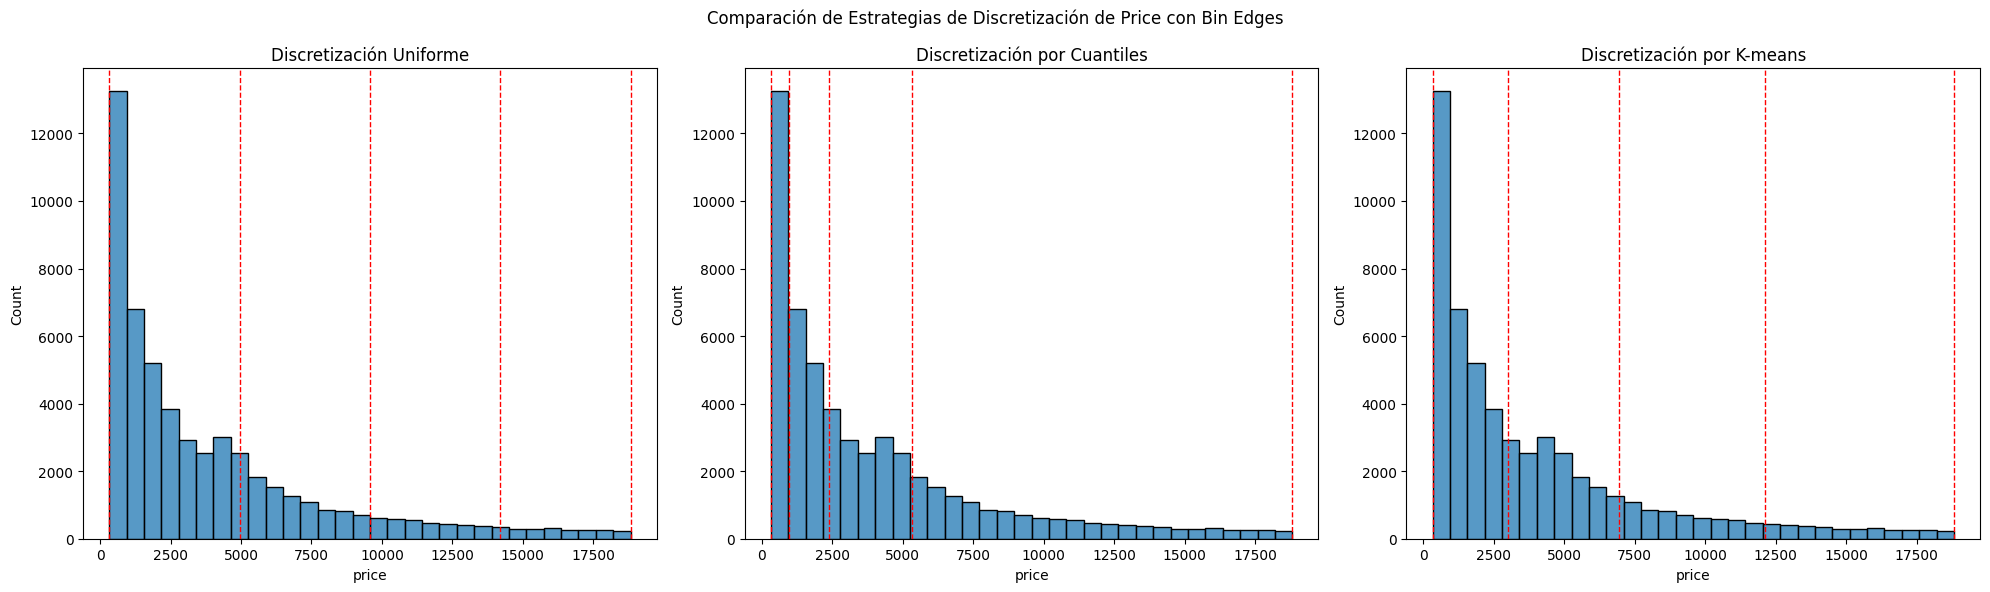

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Discretización Uniforme
sns.histplot(df_diamonds['price'], ax=axes[0], kde=False, bins=30).set_title('Discretización Uniforme')
for bin_edge in discretizer_uniform.bin_edges_[0]:
    axes[0].axvline(bin_edge, color='red', linestyle='--', linewidth=1)

# Discretización por Cuantiles
sns.histplot(df_diamonds['price'], ax=axes[1], kde=False, bins=30).set_title('Discretización por Cuantiles')
for bin_edge in discretizer_quantile.bin_edges_[0]:
    axes[1].axvline(bin_edge, color='red', linestyle='--', linewidth=1)

# Discretización por K-means
sns.histplot(df_diamonds['price'], ax=axes[2], kde=False, bins=30).set_title('Discretización por K-means')
for bin_edge in discretizer_kmeans.bin_edges_[0]:
    axes[2].axvline(bin_edge, color='red', linestyle='--', linewidth=1)

plt.suptitle('Comparación de Estrategias de Discretización de Price con Bin Edges')
plt.tight_layout()
plt.show()

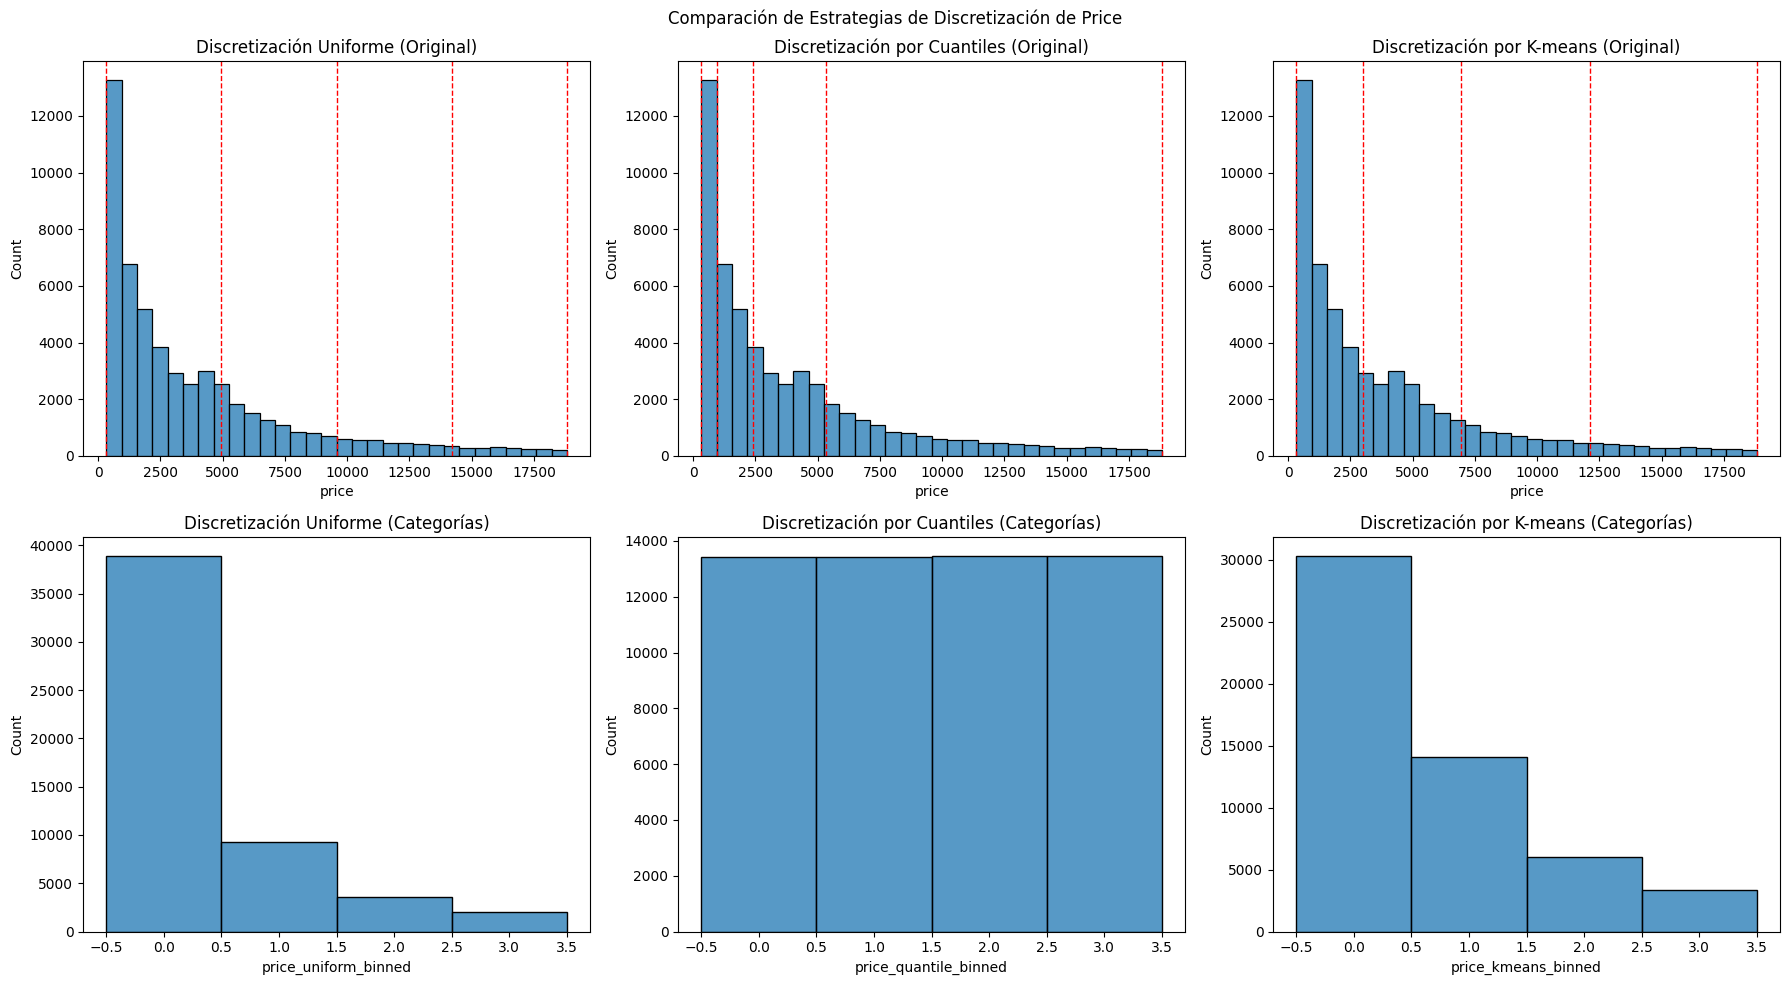

In [28]:
# Visualizar la discretización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Discretización Uniforme - Primera fila
sns.histplot(df_diamonds['price'], ax=axes[0,0], kde=False, bins=30).set_title('Discretización Uniforme (Original)')
for bin_edge in discretizer_uniform.bin_edges_[0]:
    axes[0,0].axvline(bin_edge, color='red', linestyle='--', linewidth=1)

# Discretización por Cuantiles - Primera fila
sns.histplot(df_diamonds['price'], ax=axes[0,1], kde=False, bins=30).set_title('Discretización por Cuantiles (Original)')
for bin_edge in discretizer_quantile.bin_edges_[0]:
    axes[0,1].axvline(bin_edge, color='red', linestyle='--', linewidth=1)

# Discretización por K-means - Primera fila
sns.histplot(df_diamonds['price'], ax=axes[0,2], kde=False, bins=30).set_title('Discretización por K-means (Original)')
for bin_edge in discretizer_kmeans.bin_edges_[0]:
    axes[0,2].axvline(bin_edge, color='red', linestyle='--', linewidth=1)

# Discretización Uniforme - Segunda fila (categorías)
sns.histplot(df_diamonds['price_uniform_binned'], ax=axes[1,0], discrete=True).set_title('Discretización Uniforme (Categorías)')

# Discretización por Cuantiles - Segunda fila (categorías)
sns.histplot(df_diamonds['price_quantile_binned'], ax=axes[1,1], discrete=True).set_title('Discretización por Cuantiles (Categorías)')

# Discretización por K-means - Segunda fila (categorías)
sns.histplot(df_diamonds['price_kmeans_binned'], ax=axes[1,2], discrete=True).set_title('Discretización por K-means (Categorías)')

plt.suptitle('Comparación de Estrategias de Discretización de Price')
plt.tight_layout()
plt.show()

### Numerización (de categórico a numérico)

Podemos transformar variable de cualitativas a cuantitativas. Pero la técnica a aplicar dependerá de si partimos de una variable nominal u ordinal.

Primer, tomemos una variable de tipo ordinal como la variable `cut`. Esta variable contiene 5 variables únicas: Ideal, Premium, Good, Very Good y Fair. Por su significado, vemos que este listado tiene un orden implícito, es decir podemos decir si una categoría es mayor, menor o igual a otra. Por esta característica es que podemos asignarle valores numéricos. Por ejemplo, podemos hacer un "mapeo" de cada categoría de esta forma:

|Valor original|Valor transformado|
|-|-|
|Ideal|5|
|Premium|4|
|Very Good|3|
|Good|2|
|Fair|1|

Esta técnica se denomina **numerización 1 a 1**, es decir partimos de 1 columna y terminamos con 1 columna.

In [29]:
# Escribo el mapeo. Indico qué valor le asigno a cada categoría
mapeo = {
  "Ideal":5,
  "Premium":4,
  "Very Good":3,
  "Good":2,
  "Fair":1
}

# Ejecuto el mapeo
df_diamonds["cut_encoded"] = df_diamonds["cut"].map(mapeo)

In [30]:
# Muestro un rango de filas
df_diamonds[['cut', 'cut_encoded']].iloc[0:15]

# # Muestro filas elegidas aleatoriamente
# df_diamonds[['cut', 'cut_encoded']].sample(n=15)

,cut,cut_encoded
0,Ideal,5
1,Premium,4
2,Good,2
3,Premium,4
4,Good,2
5,Very Good,3
6,Very Good,3
7,Very Good,3
8,Fair,1
9,Very Good,3


In [31]:
df_diamonds['color'].unique()

['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

Ahora, tomemos una variable de tipo nominal. Para este ejemplo usaremos la variable `color` (**Nota:** aunque puede asignarse un orden, supongamos para este ejemplo que todos los colores son igual de importantes y no hay uno mejor que otro).

Esta variable contiene 7 valores únicos: 'D', 'E', 'F', 'G', 'H', 'I' y 'J'. Como estos valores no contienen un orden, entonces no podemos aplicar la técnica antes vista, ya que al tarnsformarlo en un conjunto de números le estamos asignando sin quererlo un orden a priori.

Para evitar este problema, existe otra técnica que realiza lo siguiente: genera una columna por cada categoría y le asigna el valor True a la categoría perteneciente al registro y False a las demás columnas. Por ejemplo:

|Nº registro| . . . |color|
|-|-|-|
|1| . . . |F|
|2| . . . |D|
|3| . . . |I|

<br>

|Nº registro| . . . |color_D|color_E|color_F|color_G|color_H|color_I|color_J|
|-|-|-|-|-|-|-|-|-|
|1| . . . |False|False|**True**|False|False|False|False|
|2| . . . |**True**|False|False|False|False|False|False|
|3| . . . |False|False|False|False|False|**True**|False|

<br>

El resulto es un conjunto de columnas nuevas de tipo booleano, pero facilmente se pueden convertir a numéricas tal que False = 0 y True = 1. Así terminamos de pasar la variable cualitativa a cuantitativa.

Esta técnica se denomina **numerización 1 a n**, es decir partimos de 1 columna y terminamos con muchas columna, una por cada categoría, aunque en el mundo del análisis de datos se conoce como **One-Hot Encoding**.

In [32]:
# Preparo la transformación
one_hot_encoder = OneHotEncoder()

# Aplico la transformación
color_encoded = one_hot_encoder.fit_transform(df_diamonds[['color']])

In [33]:
# Junto el resultado con la tabla original
color_df = pd.DataFrame(color_encoded.toarray(), columns=one_hot_encoder.get_feature_names_out(['color']))
df_one_hot = pd.concat([df_diamonds.reset_index(drop=True), color_df], axis=1)
color_df

,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
53789,1.0,0.0,0.0,0.0,0.0,0.0,0.0
53790,1.0,0.0,0.0,0.0,0.0,0.0,0.0
53791,1.0,0.0,0.0,0.0,0.0,0.0,0.0
53792,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [34]:
df_one_hot.iloc[0:15]

,carat,cut,color,clarity,depth,table,price,x,y,z,price_uniform_binned,price_quantile_binned,price_kmeans_binned,cut_encoded,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.0,0.0,0.0,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.0,0.0,0.0,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.0,0.0,0.0,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.0,0.0,0.0,4,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.0,0.0,0.0,2,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49,0.0,0.0,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39,0.0,0.0,0.0,3,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Escalado: normalización y estandarización

Otra tarnsformaciones que se pueden realizar son la normalización y la estandarización. En este caso se modifican los valores de una columna medianto rangos o reglas especiales. Su objetivo es que diversas variables con unidades de medidas diferentes puedan ser comparables.

**Normalización**: Aquí se transforman todos los valores para que se ubiquen en el rango [0,1]. De esta forma, todos los valores quedan dentro de dicho intervalo.

In [35]:
# Preparo la transformación
min_max_scaler = MinMaxScaler()

# Aplico la transformación
df_diamonds['depth_minmax'] = min_max_scaler.fit_transform(df_diamonds[['depth']])

In [36]:
# Muestro las columnas transformadas
df_diamonds[['depth', 'depth_minmax']].describe()

,depth,depth_minmax
count,53794.000000,53794.000000
mean,61.748080,0.520780
std,1.429909,0.039720
min,43.000000,0.000000
25%,61.000000,0.500000
50%,61.800000,0.522222
75%,62.500000,0.541667
max,79.000000,1.000000


**Estandarización**: Aquí se aplica la regla de estandarización de la distribución normal. Es decir, los valores se restan por su media y se dividen por su desvío estándar. Así tenemos una nueva distribución de los datos centrados en 0 y con desvío estándar igual a 1.

In [37]:
# Preparo la transformación
standard_scaler = StandardScaler()

# Aplico la transformación
df_diamonds['depth_standard'] = standard_scaler.fit_transform(df_diamonds[['depth']])


In [38]:
# Muestro las columnas transformadas
df_diamonds[['depth', 'depth_standard']].describe()

,depth,depth_standard
count,53794.000000,5.379400e+04
mean,61.748080,-1.102389e-15
std,1.429909,1.000009e+00
min,43.000000,-1.311150e+01
25%,61.000000,-5.231708e-01
50%,61.800000,3.631054e-02
75%,62.500000,5.258567e-01
max,79.000000,1.206516e+01


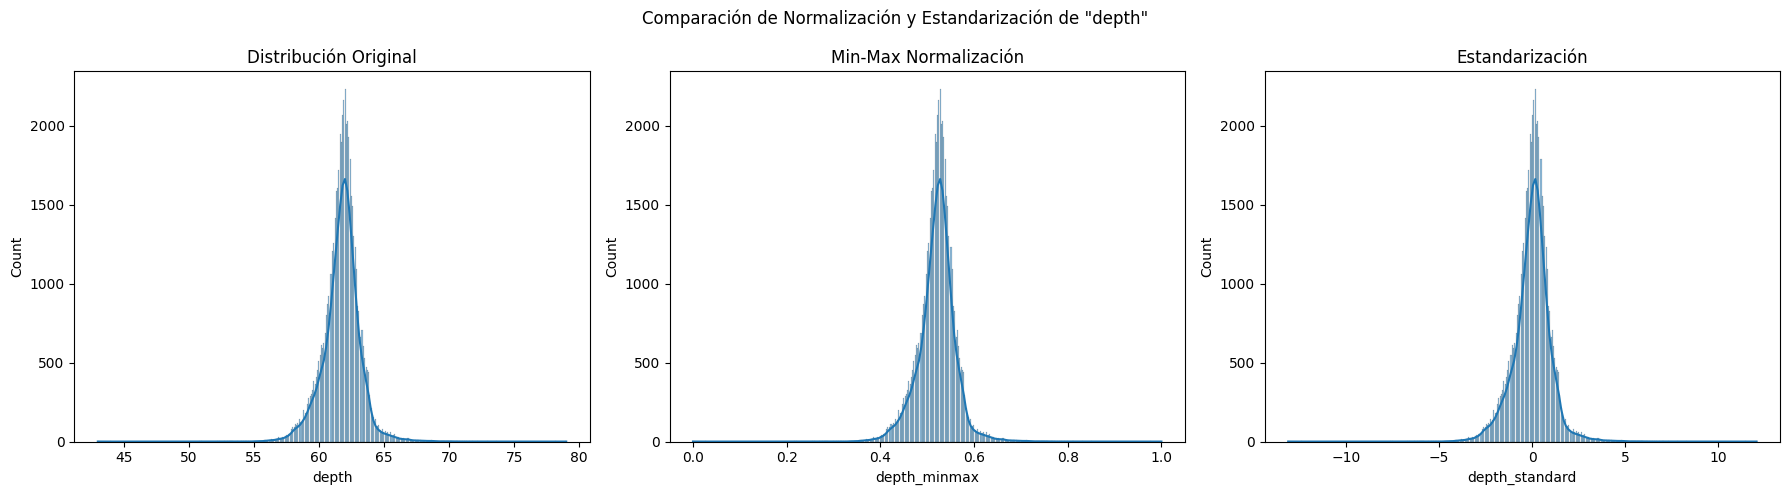

In [39]:
# Visualizar la normalización y estandarización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_diamonds['depth'], ax=axes[0], kde=True).set_title('Distribución Original')
sns.histplot(df_diamonds['depth_minmax'], ax=axes[1], kde=True).set_title('Min-Max Normalización')
sns.histplot(df_diamonds['depth_standard'], ax=axes[2], kde=True).set_title('Estandarización')
plt.suptitle('Comparación de Normalización y Estandarización de "depth"')
plt.tight_layout()
plt.show()

### Otras técnicas de transformación de datos

Existen muchas otras formas de modificar y crear variables para cambiar la forma de expresar los datos.

**Derivación**: se puede crear una nueva variable a partir de realizar cálculos con valores de otras varibles. Por ejemplo, podemos obtener una nueva variable que permita medir la relación que hay entre el peso y el precio de un diamante. También se podría calcular el volumen del diamante (`x*y*z`).

In [40]:
df_diamonds['relacion_peso_precio'] = df_diamonds['price'] / df_diamonds['carat']
df_diamonds['relacion_peso_precio']

,relacion_peso_precio
0,1417.391304
1,1552.380952
2,1421.739130
3,1151.724138
4,1080.645161
...,...
53935,3829.166667
53936,3829.166667
53937,3938.571429
53938,3205.813953


**Separación de atributos**: Puede que una variable contengan valores de tal forma que cada uno contenga más de un dato. Por ejemplo, el CUIT o CUIL de una persona contiene el código que indica el sexo, el número de DNI y un número de validación.

En el caso de los diamantes, podemos considerar que la varibale `clarity` puede dividirse en distintos atributos.

In [41]:
df_diamonds['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [42]:
df_diamonds['clarity_str'] = df_diamonds['clarity'].astype(str)
df_diamonds['clarity_cod'] = df_diamonds['clarity_str'].str.extract(r'([A-Za-z]+)', expand=False)
df_diamonds['clarity_num'] = df_diamonds['clarity_str'].str.extract(r'(\d+)', expand=False).astype(float)
df_diamonds[['clarity', 'clarity_cod', 'clarity_num']]

,clarity,clarity_cod,clarity_num
0,SI2,SI,2.0
1,SI1,SI,1.0
2,VS1,VS,1.0
3,VS2,VS,2.0
4,SI2,SI,2.0
...,...,...,...
53935,SI1,SI,1.0
53936,SI1,SI,1.0
53937,SI1,SI,1.0
53938,SI2,SI,2.0


# Práctica autónoma

## Dataset: Penguins

Trabajaremos con el dataset 'Penguins'. Este conjunto de datos contiene información biométrica sobre tres especies diferentes de pingüinos (Adelie, Chinstrap, Gentoo) que habitan en varias islas del archipiélago Palmer en la Antártida.

Tu objetivo será aplicar varias de las técnicas de transformación de datos.

Aquí se describen en detalle las variables del dataset:

| Variable          | Descripción|
| :---------------- | - |
| `species`         | Especie de pingüino (Adelie, Chinstrap, Gentoo).|
| `island`| Isla donde se recogieron los datos (Torgersen, Biscoe, Dream).|
| `bill_length_mm`  | Longitud del pico (culmen) en milímetros.|
| `bill_depth_mm`   | Profundidad del pico (culmen) en milímetros.|
| `flipper_length_mm` | Longitud de la aleta en milímetros.|
| `body_mass_g`     | Masa corporal en gramos.|
| `sex`             | Sexo del pingüino (Male, Female).|

Con la siguiente celda podrás obtener el dataset completo. Si llega a generar errores o problemas, podés descargar el dataset que está subido en el aula virtual, subirlo a la carpeta "Archivos" de colab y ejecutar el siguiente código:

```
df_penguins = pd.load_csv('\content\penguins.csv')
```

In [43]:
import seaborn as sns

# Cargar el dataset 'penguins' de seaborn
df_penguins = sns.load_dataset('penguins')

## Consignas
1. Realizar la observación del dataset, identificando la cantidad de filas, la cantidad de columnas, el tipo de cada variable y haciendo un análisis estadístico descritivo de todo el dataset.
2. Realizar el paso de limpieza de datos realizando únicamente el tratamiento de valores nulos.
3. Realizá las siguientes transformaciones:

* a) **Discretizá** la columna `flipper_length_mm` en 4 tramos usando una estrategia de cuantiles. Creá una nueva columna llamada `flipper_length_category`. Mostrá las 10 primeras filas del DataFrame con la nueva columna para verificar el resultado.
* b) La columna `island` es una variable categórica con 3 valores posibles.Aplicá **One-Hot Encoding** para transformarla en variables binarias. Creá nuevas columnas llamadas `island_torgersen`, `island_biscoe` e `island_dream`. Eliminá la columna original del DataFrame. Mostrá las primeras 10 filas del DataFrame para inspeccionar los resultados.
* c) La columna `bill_length_mm` tiene una dispersión que conviene acotar. Además, la variable `body_mass_g` está medida en gramos, una escala muy diferente a la del resto de las variables, que están en milímetros. Escalá la variable `bill_length_mm` usando normalización (Escala Min-Max) para que los valores queden en el rango [0,1]. Creá una nueva columna llamada `bill_length_minmax`.
* d) Estandarizá la variable `body_mass_g` para que tenga una media de 0 y una desviación estándar de 1. Creá una nueva columna llamada `body_mass_standard`. Mostrá las primeras 10 filas del DataFrame con las nuevas columnas.
* e) Creá una nueva variable que se calcule como la división entre `bill_length_mm` y `bill_depth_mm`. Llamá a esta nueva columna `bill_ratio`.

4. Incorporá las cuatro decisiones a una nueva bitácora (como en la práctica de la semana 4) y justificá para qué podría servir cada transformación.

**NOTA**: Conservá las variables originales y revisá los resultados antes de dar por finalizada la práctica.